# Audio Feature Analysis (Spotify Tracks Dataset)

## 0.1. Introduction

The goal of this project is to analyze which audio features influence the popularity of a song on Spotify.

Based on this analysis, machine learning models will be developed to predict a track's popularity and classify whether a song can be considered a "hit".

This problem combines exploratory analysis, regression, classification, and model interpretation.

## 0.2. Dataset Description

The dataset contains information about Spotify tracks with detailed audio features.

- Number of observations: ~114,000 tracks
- Unit of analysis: 1 row = 1 track

The dataset includes track metadata (name, artist, album) and detailed audio feature metrics calculated by Spotify's audio analysis algorithms.

## 0.3. Audio Features

The dataset contains the following key audio features:

- **Acousticness**: confidence measure of whether the track is acoustic (0.0 - 1.0)
- **Danceability**: suitability of a track for dancing (0.0 - 1.0)
- **Energy**: intensity and activity level (0.0 - 1.0)
- **Instrumentalness**: likelihood that the track is instrumental (0.0 - 1.0)
- **Liveness**: presence of a live audience (0.0 - 1.0)
- **Loudness**: overall volume in decibels (dB)
- **Speechiness**: presence of spoken words (0.0 - 1.0)
- **Tempo**: speed and rhythm in beats per minute (BPM)
- **Valence**: musical positivity/happiness (0.0 - 1.0)
- **Popularity**: Spotify popularity score (0 - 100)

## 0.4. Project Objectives

1. Analyze the distribution of audio features  
2. Study the relationship between these features and popularity  
3. Identify the most influential variables  
4. Build regression models to predict popularity  
5. Build classification models to identify successful songs  
6. Interpret the models and draw relevant conclusions  

## 0.5. Project Structure

The analysis will follow these phases:

1. Data loading and exploration  
2. Exploratory data analysis (EDA)  
3. Data preparation  
4. Regression models  
5. Classification models  
6. Evaluation and comparison  
7. Model interpretation  
8. Conclusions  
---

# 1. Data Loading and Exploration

## 1.1 Required Library Imports

We import the necessary libraries for data manipulation and analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Basic configuration
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1.2. Loading the Dataset

The dataset is loaded from a CSV file downloaded from Kaggle. The file should be placed in the `data/` folder.

In [2]:
df = pd.read_csv("../data/spotify-tracks.csv")

## 1.3. Initial Data Exploration

We examine the first rows of the dataset to understand its structure.

In [3]:
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dataset Dimensions and Basic Information

In [4]:
print(f"Dataset dimensions: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset dimensions: (114000, 20)

Number of rows: 114000
Number of columns: 20


### Data Types and Missing Values

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

In [6]:
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

Only 3 null values were detected in text columns. Being a negligible number compared to the 114,000 records, they have been directly removed without impact on the analysis.

In [7]:
df = df.dropna()

### Statistical Summary

In [8]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 1.4 Duplicate Treatment

The existence of duplicate songs was detected in the dataset, mainly due to the presence of the same track across different genres or albums.

To avoid bias in the analysis, duplicates were removed based on `track_id`, keeping a single record per song.

### Exploring a Specific Case

In [9]:
duplicated_ids = df[df.duplicated(subset='track_id', keep=False)]

# View a specific duplicate example
example_id = duplicated_ids['track_id'].value_counts().index[0]
df[df['track_id'] == example_id][['track_id', 'track_name', 'artists', 'album_name', 'track_genre', 'popularity']]

,track_id,track_name,artists,album_name,track_genre,popularity
8315,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),blues,67
19759,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),country,67
34728,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),folk,67
62226,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),j-pop,67
63087,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),j-rock,67
82064,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),power-pop,67
84129,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),psych-rock,67
99727,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),singer-songwriter,67
102732,6S3JlDAGk3uu3NtZbPnuhS,Baby Blue - Remastered 2010,Badfinger,Straight Up (Remastered 2010 / Deluxe Edition),songwriter,67


### Removing Duplicate Values

In [10]:
print(f"Rows before removing duplicates: {df.shape[0]}")
df = df.drop_duplicates(subset='track_id', keep='first')
print(f"Rows after removing duplicates: {df.shape[0]}")

Rows before removing duplicates: 113999
Rows after removing duplicates: 89740


---

# 2. Exploratory Data Analysis (EDA)

### Objective

Analyze the distribution of variables and their relationship with popularity to identify relevant patterns.

## 2.1. Audio Feature Distribution

We analyze the distribution of the main audio features to understand their characteristics.

In [11]:
# Select numeric columns for analysis
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric columns: {numeric_cols}")

Numeric columns: ['popularity', 'duration_ms', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']


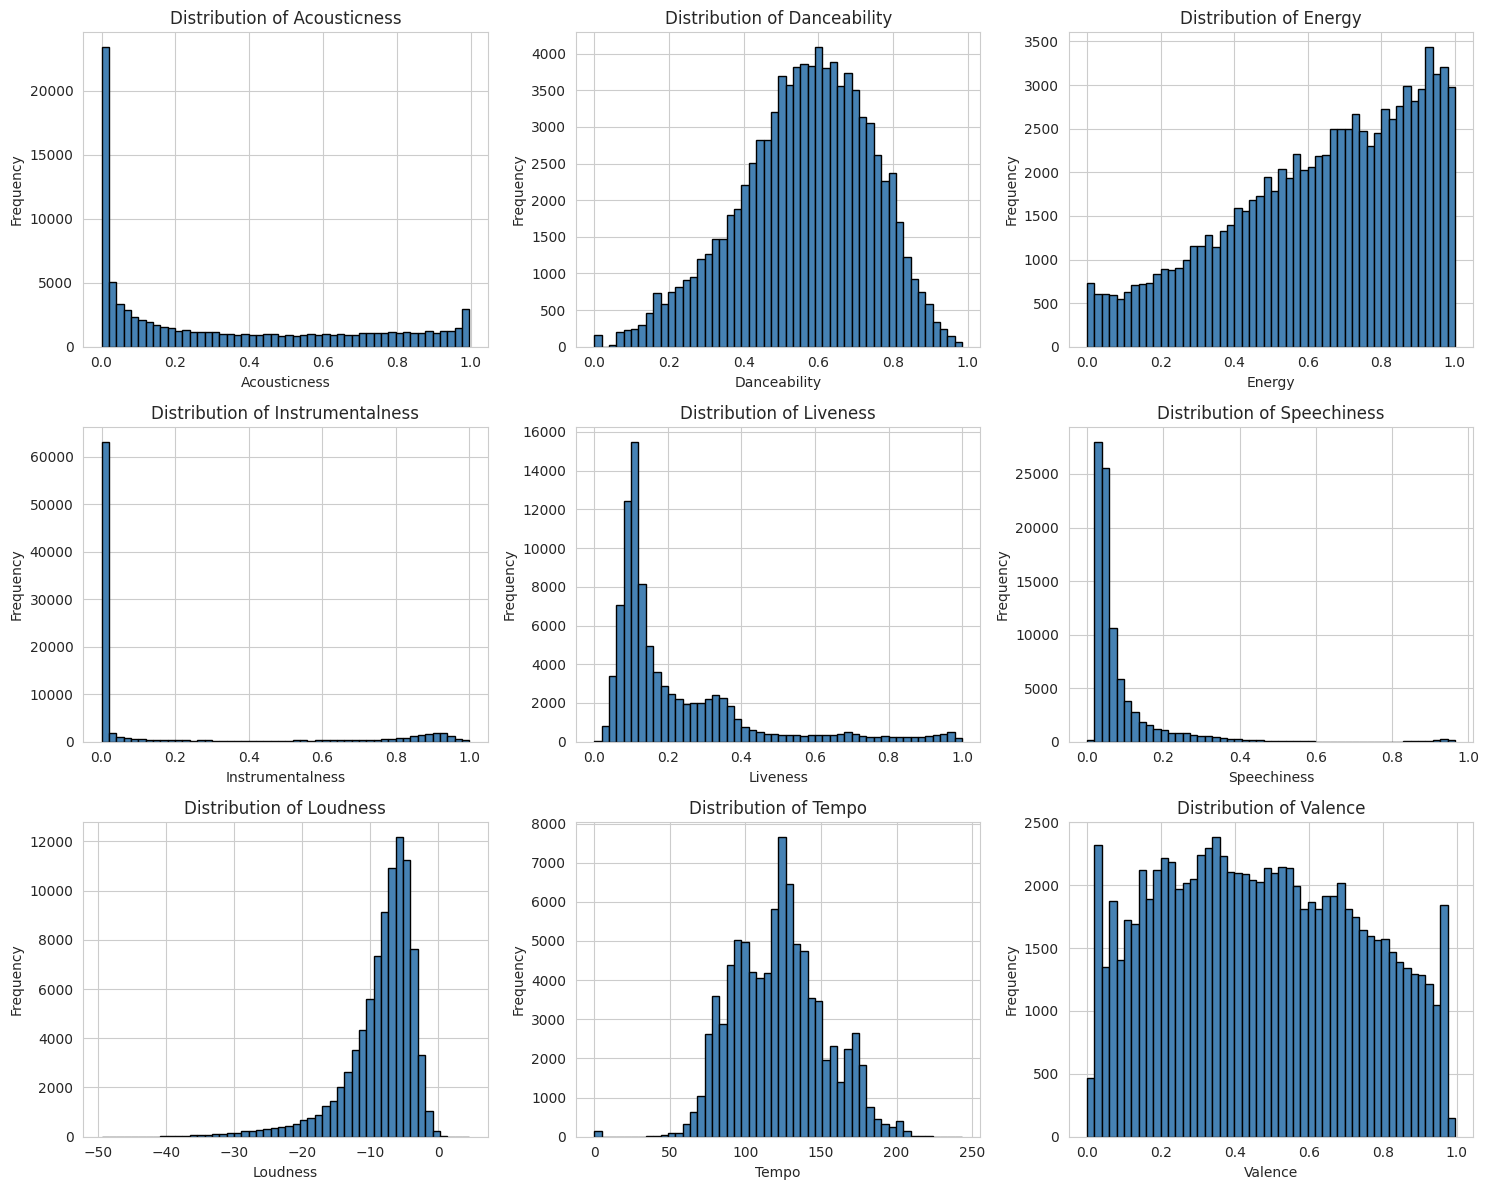

In [12]:
# Audio feature distribution plots
audio_features = ['acousticness', 'danceability', 'energy', 'instrumentalness', 
                   'liveness', 'speechiness', 'loudness', 'tempo', 'valence']

available_features = [col for col in audio_features if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available_features[:9]):
    axes[idx].hist(df[feature].dropna(), bins=50, color='steelblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {feature.title()}')
    axes[idx].set_xlabel(feature.title())
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation

- **Acousticness** shows a bimodal distribution: many tracks with very low values (electronic productions) and another group with high values (acoustic tracks).
- **Danceability** and **energy** are concentrated in medium-high values, reflecting that Spotify tracks tend to be energetic and danceable.
- **Instrumentalness**, **liveness**, and **speechiness** show heavily right-skewed distributions: the vast majority of tracks have low values, with a long tail toward high values.
- **Loudness** shows negative skew, with most tracks between -10 dB and -5 dB.
- **Tempo** follows an approximately normal distribution centered around ~120 BPM.
- **Valence** is distributed approximately uniformly, indicating a balanced variety between "sad" and "happy" tracks.

## 2.2. Popularity Analysis

Let's examine how track popularity is distributed in the dataset.

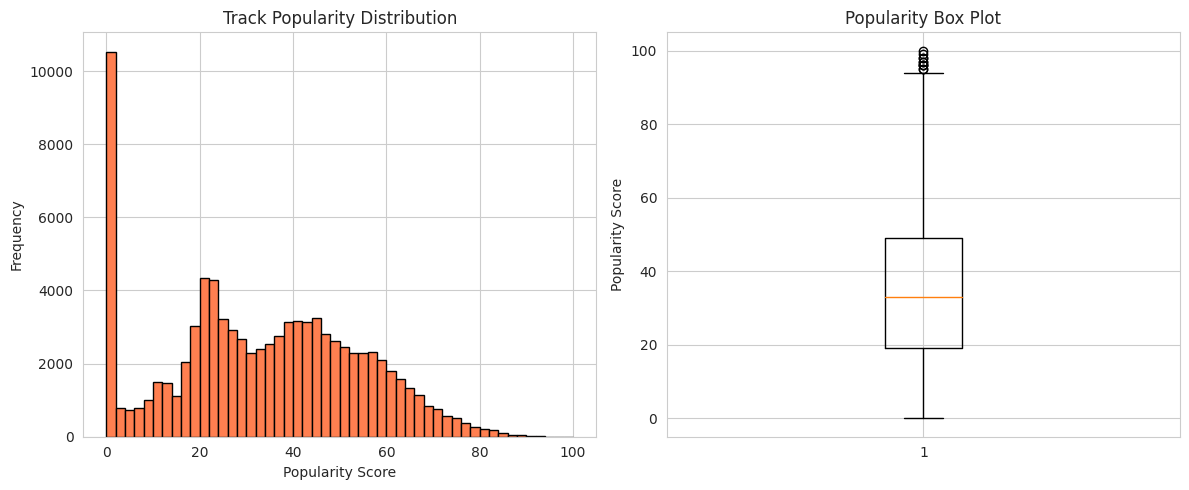


Popularity Statistics:
count    89740.000000
mean        33.198808
std         20.580640
min          0.000000
25%         19.000000
50%         33.000000
75%         49.000000
max        100.000000
Name: popularity, dtype: float64


In [13]:
if 'popularity' in df.columns:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(df['popularity'].dropna(), bins=50, color='coral', edgecolor='black')
    plt.title('Track Popularity Distribution')
    plt.xlabel('Popularity Score')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(df['popularity'].dropna())
    plt.title('Popularity Box Plot')
    plt.ylabel('Popularity Score')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPopularity Statistics:")
    print(df['popularity'].describe())

### Interpretation

- The popularity distribution is approximately symmetric, with mean (~33) and median (33) very close together.
- 10.5% of tracks have a popularity of 0, suggesting tracks with barely any plays or very recent releases.
- Only ~3% of tracks exceed a popularity of 70, confirming that "hits" are a minority.
- The box plot shows moderate dispersion without obvious extreme outliers.
- The large concentration of tracks in the 15–50 range indicates that most songs have low-to-moderate popularity.

## 2.3. Popularity Analysis by Genre

We examine how average popularity varies across different musical genres in the dataset. This allows us to identify which genres tend to produce more popular songs on Spotify.

### Top Genres

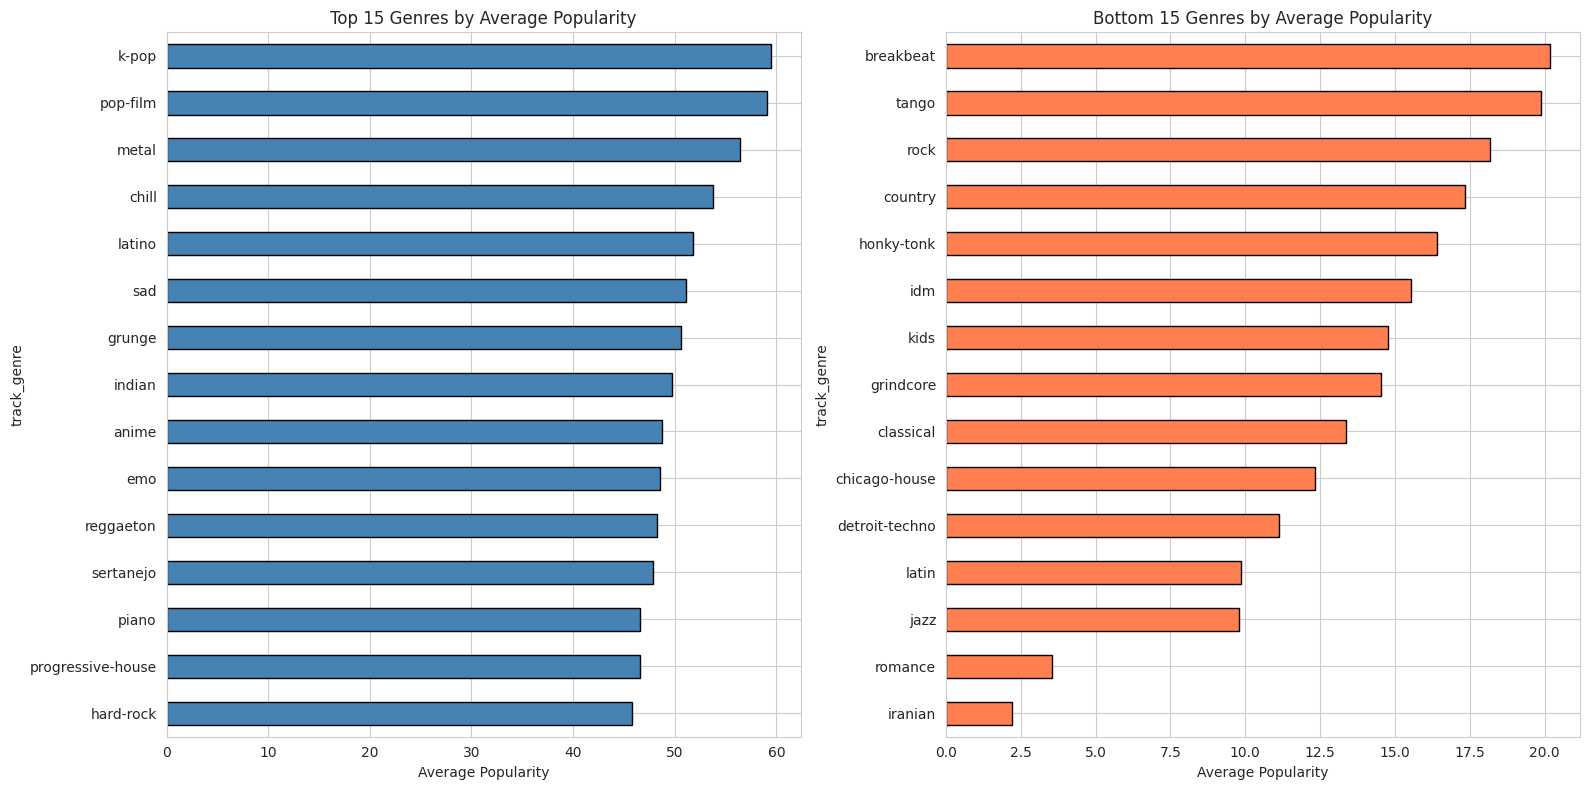

In [14]:
# Average popularity by genre
genre_popularity = df.groupby('track_genre')['popularity'].agg(['mean', 'median', 'count'])
genre_popularity.columns = ['mean', 'median', 'count']
genre_popularity = genre_popularity.sort_values('mean', ascending=False)

# Top 15 most popular genres
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 15
genre_popularity['mean'].head(15).plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Top 15 Genres by Average Popularity')
axes[0].set_xlabel('Average Popularity')
axes[0].invert_yaxis()

# Bottom 15
genre_popularity['mean'].tail(15).plot(
    kind='barh', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('Bottom 15 Genres by Average Popularity')
axes[1].set_xlabel('Average Popularity')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Interpretation

- The most popular genres (k-pop, pop-film, metal) reach average popularity around 55–60, well above the global average (~33).
- The least popular genres (iranian, romance, jazz, latin) have averages below 10, indicating niches with smaller audiences on the platform.
- The difference between the most and least popular genres exceeds 55 points, showing enormous variability across genres.

### Distribution by Genre

/tmp/ipykernel_1748224/2140728774.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='track_genre', y='popularity', order=order, palette='viridis')


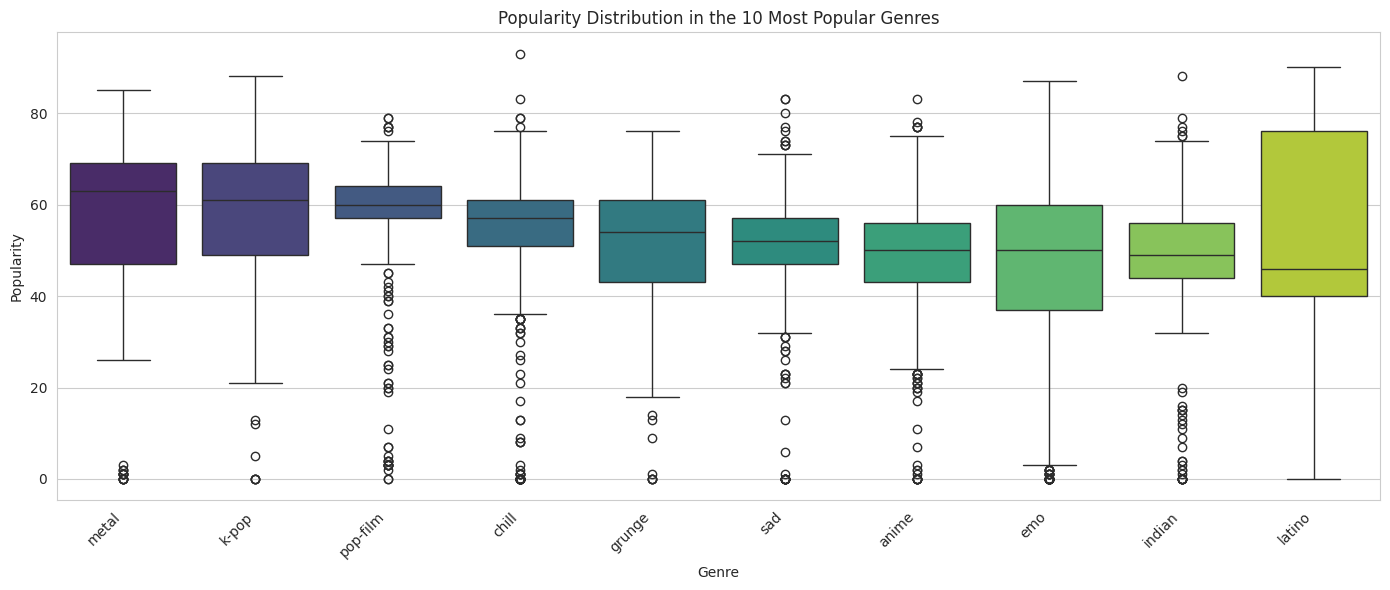

In [15]:
# Popularity boxplot for the 10 most popular genres
top_genres = genre_popularity.head(10).index.tolist()

plt.figure(figsize=(14, 6))
df_top = df[df['track_genre'].isin(top_genres)]
order = df_top.groupby('track_genre')['popularity'].median().sort_values(ascending=False).index

sns.boxplot(data=df_top, x='track_genre', y='popularity', order=order, palette='viridis')
plt.title('Popularity Distribution in the 10 Most Popular Genres')
plt.xlabel('Genre')
plt.ylabel('Popularity')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Interpretation

- Even within the most popular genres, there is great dispersion in the popularity of individual tracks: genre establishes a base range but does not guarantee success.
- Medians vary considerably among top 10 genres, reinforcing that popularity depends on both genre and individual characteristics of each song.

### Audio Features by Genre

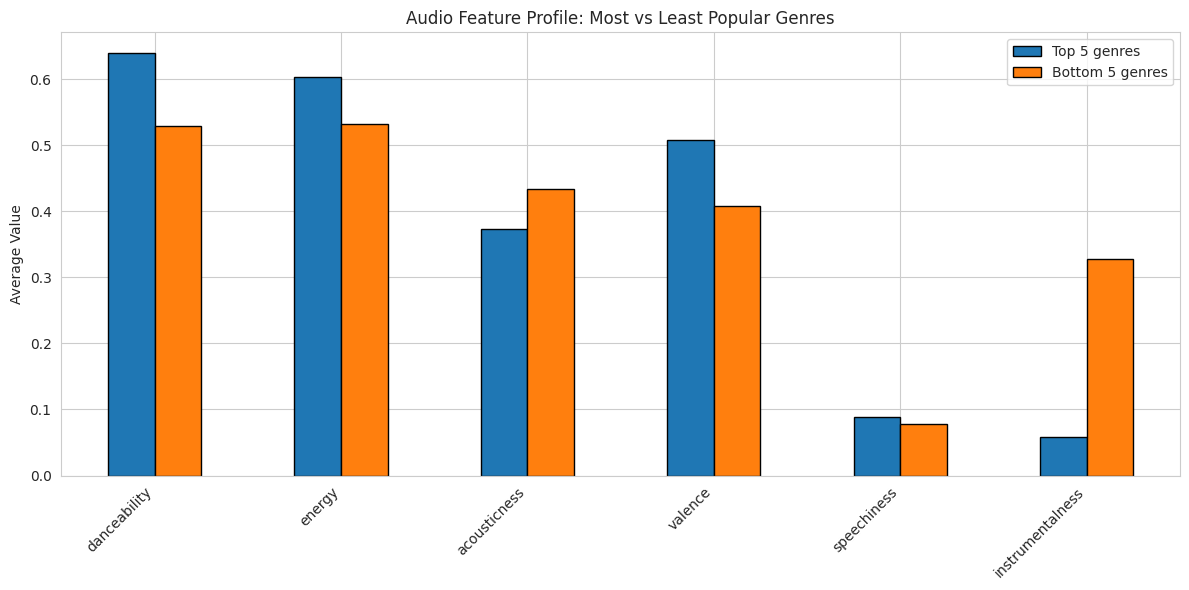

                  Top 5 genres  Bottom 5 genres
danceability             0.639            0.529
energy                   0.603            0.532
acousticness             0.373            0.434
valence                  0.509            0.408
speechiness              0.089            0.078
instrumentalness         0.059            0.328


In [16]:
# Audio feature profile of the 5 most and least popular genres
top_5 = genre_popularity.head(5).index.tolist()
bottom_5 = genre_popularity.tail(5).index.tolist()

audio_features_comparision = ['danceability', 'energy', 'acousticness', 'valence', 'speechiness', 'instrumentalness']

profile_top = df[df['track_genre'].isin(top_5)][audio_features_comparision].mean()
profile_bottom = df[df['track_genre'].isin(bottom_5)][audio_features_comparision].mean()

comparison = pd.DataFrame({
    'Top 5 genres': profile_top,
    'Bottom 5 genres': profile_bottom
})

comparison.plot(kind='bar', figsize=(12, 6), edgecolor='black')
plt.title('Audio Feature Profile: Most vs Least Popular Genres')
plt.ylabel('Average Value')
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(comparison.round(3))

### Interpretation

- There is significant variability in average popularity between genres, suggesting that genre is a relevant factor in a track's popularity.
- The most popular genres tend to show higher danceability and energy, while the least popular show higher instrumentalness and acousticness.
- The dispersion within each genre (visible in the box plots) indicates that genre alone does not determine popularity, but it does establish a base range.

## 2.4. Outlier Detection in Audio Features

We identify outliers in audio features that could affect model performance.

### Visualization

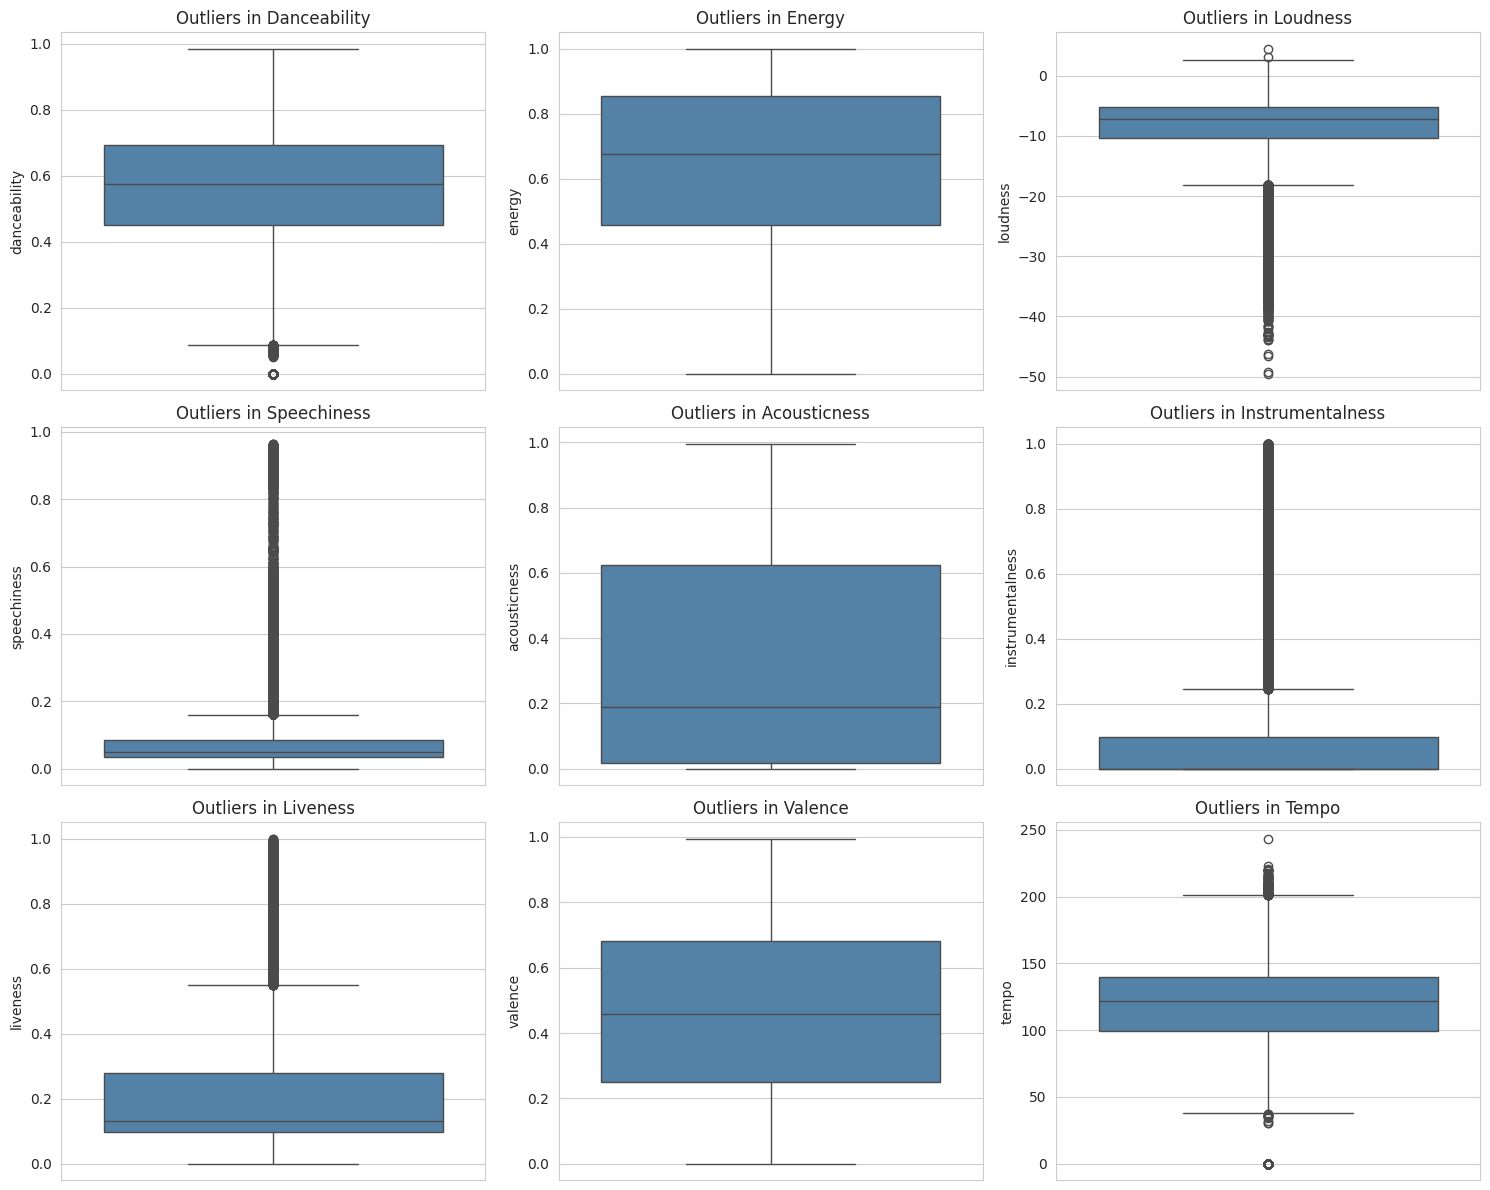

In [17]:
audio_features_full = ['danceability', 'energy', 'loudness', 'speechiness', 
                       'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

available = [col for col in audio_features_full if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(available[:9]):
    sns.boxplot(data=df, y=feature, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Outliers in {feature.title()}')

plt.tight_layout()
plt.show()

### Interpretation

- Variables with the most skewed distributions (**speechiness**, **liveness**, **instrumentalness**) produce the most outliers according to the IQR method, as most values are concentrated near 0.
- **Loudness** shows outliers at the lower extreme (exceptionally quiet tracks, down to -49 dB).
- **Danceability**, **energy**, and **valence**, having more symmetric distributions, generate few outliers.

### Quantification

In [18]:
# Count outliers using IQR method
outlier_summary = []

for feature in available:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[feature] < lower) | (df[feature] > upper)).sum()
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'feature': feature,
        'outliers': n_outliers,
        'percentage': round(pct, 2),
        'lower_bound': round(lower, 3),
        'upper_bound': round(upper, 3)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('percentage', ascending=False)
print(outlier_df.to_string(index=False))

         feature  outliers  percentage  lower_bound  upper_bound
instrumentalness     19613       21.86       -0.146        0.244
     speechiness     10644       11.86       -0.039        0.161
        liveness      6981        7.78       -0.173        0.550
        loudness      5026        5.60      -18.144        2.713
           tempo       514        0.57       38.041      201.298
    danceability       474        0.53        0.087        1.055
          energy         0        0.00       -0.137        1.447
    acousticness         0        0.00       -0.895        1.537
         valence         0        0.00       -0.401        1.332


### Interpretation

- Variables like `instrumentalness`, `speechiness`, and `liveness` have highly skewed distributions, generating a high number of outliers according to the IQR method.
- These outliers are not necessarily errors; they represent songs with extreme characteristics (e.g., purely instrumental tracks or spoken word).
- For tree-based models (Random Forest, XGBoost), it is not necessary to remove them. For linear or distance-based models, logarithmic transformations or winsorization should be considered.

## 2.5 Correlation Between Variables

### Objective

Analyze the relationship between numeric variables in the dataset to identify possible dependencies and their relationship with popularity.

A correlation matrix is used to visualize these relationships.

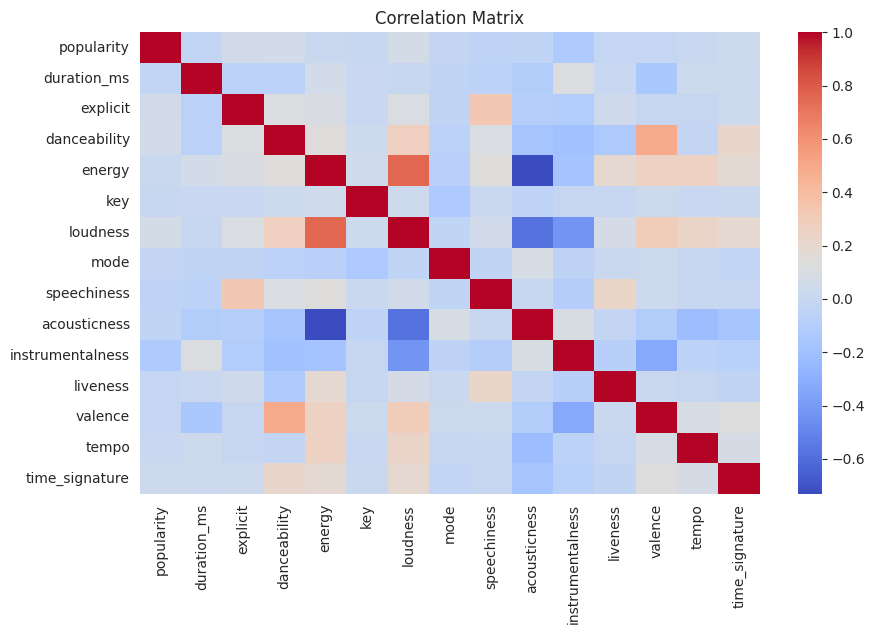

In [19]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Observations

- No very strong correlations are observed between most variables  
- Some variables like `energy`, `loudness`, or `danceability` show some relationship with popularity  
- Popularity does not depend on a single variable, but on a combination of factors  

This reinforces the need to use machine learning models to capture more complex relationships.

## 2.6. Relationship Between Audio Features and Popularity

We analyze how individual audio features relate to track popularity.

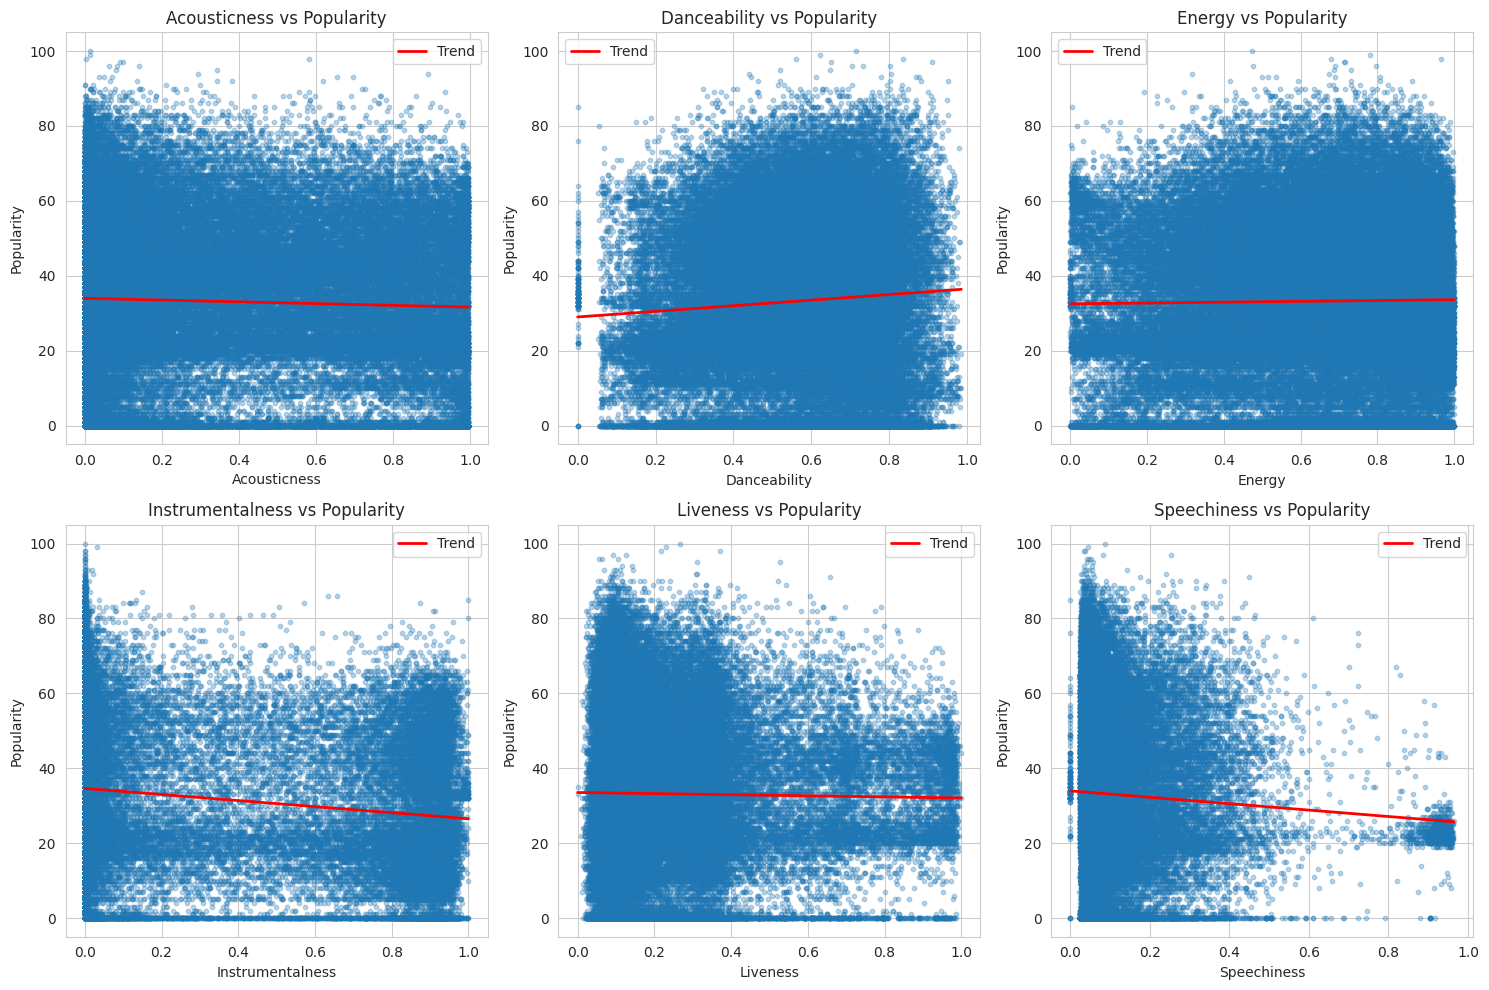

In [20]:
if 'popularity' in df.columns and len(available_features) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    features_to_plot = available_features[:6]
    
    for idx, feature in enumerate(features_to_plot):
        axes[idx].scatter(df[feature], df['popularity'], alpha=0.3, s=10)
        axes[idx].set_xlabel(feature.title())
        axes[idx].set_ylabel('Popularity')
        axes[idx].set_title(f'{feature.title()} vs Popularity')
        
        # Add trend line
        mask = df[feature].notna() & df['popularity'].notna()
        z = np.polyfit(df.loc[mask, feature], df.loc[mask, 'popularity'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
        axes[idx].plot(x_line, p(x_line), 'r-', linewidth=2, label='Trend')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()

### Interpretation

- No strong linear relationships are observed between individual audio features and popularity; the scatter plots show dispersed point clouds.
- The most notable correlation is **instrumentalness** with popularity (r ≈ −0.13): more instrumental tracks tend to be less popular.
- **Loudness** (r ≈ 0.07) and **danceability** (r ≈ 0.06) show slight positive correlations.
- These weak correlations confirm that popularity does not depend on a single variable, which justifies the use of multivariate models in the following phases.

---

# 3. Data Preparation

## 3.1. Variable Selection and Transformation

In this phase, variables are selected and transformed for use in machine learning models.

Variables that do not provide predictive value or cannot be directly used by the models are removed, such as identifiers or free-text variables.

Additionally, a specific dataset for modeling (`df_model`) is built, keeping the original dataset for exploratory analysis.

In [21]:
df_model = df.copy()

cols_to_drop = ["track_name", "artists", "album_name", "track_id", "track_genre"]

df_model = df_model.drop(columns=[col for col in cols_to_drop if col in df_model.columns])

## 3.2 Variable Separation

In this phase, the target variable (`popularity`) is separated from the rest of the predictor variables.

In [22]:
X = df_model.drop(columns=["popularity"])
y = df_model["popularity"]

## 3.3. Train-Test Split

The dataset is split into training and test sets to properly evaluate the models.

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 3.4. Feature Scaling

Some models require scaled features.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3.5. Classification Preparation

A binary variable `hit` is defined to transform the problem into classification, allowing identification of songs with high popularity.  

Before defining the variable, let's perform a brief percentile analysis to justify the threshold.

In [25]:
# Percentile analysis to justify the threshold
print("Popularity percentiles:")
for p in [50, 70, 75, 80, 90, 95]:
    print(f"  Percentile {p}: {df_model['popularity'].quantile(p/100):.0f}")

Popularity percentiles:
  Percentile 50: 33
  Percentile 70: 45
  Percentile 75: 49
  Percentile 80: 52
  Percentile 90: 60
  Percentile 95: 67


### Threshold Justification

The percentiles show that the popularity distribution has the following structure:

| Percentile | Popularity |
|-----------|-------------|
| 50 | 33 |
| 70 | 45 |
| **75** | **49** |
| 80 | 52 |
| 90 | 60 |
| 95 | 67 |

The threshold of **popularity > 49** (75th percentile) is defined to classify a song as a "hit". This value divides the dataset into a **75% non-hit / 25% hit** ratio, which:

- Is selective enough so that "hit" represents songs that stand out above the majority.
- Generates a moderate imbalance (3:1), manageable by classification algorithms without mandatory resampling techniques.
- Avoids the extreme imbalance of higher thresholds (e.g., popularity > 70 would leave only 3% of hits, making detection impossible for most models).

In [26]:
df_model["hit"] = (df_model["popularity"] > 49).astype(int)
print(f"Distribution of 'hit' variable (threshold > 49):")
print(df_model["hit"].value_counts())
print(f"\nProportion: {df_model['hit'].value_counts(normalize=True).round(3).to_dict()}")

Distribution of 'hit' variable (threshold > 49):
hit
0    68531
1    21209
Name: count, dtype: int64

Proportion: {0: 0.764, 1: 0.236}


In [27]:
X_class = df_model.drop(columns=["popularity", "hit"])
y_class = df_model["hit"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

print(f"Classification variables: {X_class.columns.tolist()}")
print(f"Class distribution:\n{y_class.value_counts(normalize=True).round(3)}")

Classification variables: ['duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature']
Class distribution:
hit
0    0.764
1    0.236
Name: proportion, dtype: float64


### Imbalance Interpretation

The class distribution shows a **moderate imbalance**: approximately 75% of tracks are "No Hit" and 25% are "Hit" (3:1 ratio).

This level of imbalance is common in real-world classification problems and standard models should be able to handle it reasonably:
- A classifier that always predicts "No Hit" would achieve an **accuracy of 75%**, so accuracy is not as misleading as it would be with 97%.
- However, **F1-Score** remains the key metric for evaluating hit detection capability.
- The 3:1 ratio allows models to see enough examples of the "Hit" class during training.

---

# 4. Regression Models

### Objective

Build machine learning models capable of predicting the popularity score (0–100) of a song based on its audio features.

Models of increasing complexity will be compared: from simple linear regression to tree-based ensemble models.

## 4.1. Baseline Model: Linear Regression

Ordinary linear regression is used as the baseline model. Being the simplest model, it establishes a reference point for comparison with more complex models.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("=== Linear Regression ===")
print(f"RMSE : {rmse_lr:.3f}")
print(f"MAE  : {mae_lr:.3f}")
print(f"R²   : {r2_lr:.4f}")

=== Linear Regression ===
RMSE : 20.128
MAE  : 16.584
R²   : 0.0313


### Interpretation

The linear regression model achieves an **R² = 0.031**, meaning it only explains **3.1% of the variance** in popularity. This is a very poor result.

- An **RMSE of 20.1** on a 0–100 scale implies that predictions deviate, on average, ±20 points from the actual popularity — a margin too wide to be useful.
- This confirms what was observed in the EDA: individual linear correlations between audio features and popularity are very weak (the strongest being instrumentalness at r ≈ −0.13).
- The linear model assumes linear and additive relationships, which is an excessive simplification for this problem.

**Conclusion**: linear regression is not adequate, but it serves its purpose as a **baseline** against which to compare more complex models.

## 4.2. Regularization: Ridge and Lasso

Regularized regression models are applied to evaluate whether coefficient penalization improves generalization.

- **Ridge (L2)**: penalizes the magnitude of coefficients, reduces overfitting.
- **Lasso (L1)**: in addition to regularization, can eliminate irrelevant variables (coefficients = 0).

In [29]:
from sklearn.linear_model import Ridge, Lasso

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("=== Ridge (α=1.0) ===")
print(f"RMSE : {rmse_ridge:.3f}")
print(f"MAE  : {mae_ridge:.3f}")
print(f"R²   : {r2_ridge:.4f}")
print()
print("=== Lasso (α=0.1) ===")
print(f"RMSE : {rmse_lasso:.3f}")
print(f"MAE  : {mae_lasso:.3f}")
print(f"R²   : {r2_lasso:.4f}")
print()

# Lasso coefficients (eliminated variables)
lasso_coefs = pd.Series(lasso.coef_, index=X.columns)
print("Lasso Coefficients:")
print(lasso_coefs.round(4).to_string())

=== Ridge (α=1.0) ===
RMSE : 20.128
MAE  : 16.584
R²   : 0.0313

=== Lasso (α=0.1) ===
RMSE : 20.128
MAE  : 16.613
R²   : 0.0313

Lasso Coefficients:
duration_ms        -0.3056
explicit            1.0225
danceability        1.5301
energy             -0.0000
key                -0.0000
loudness            0.0878
mode               -0.2250
speechiness        -1.6382
acousticness       -0.1966
instrumentalness   -2.7940
liveness            0.0000
valence            -1.9449
tempo               0.0475
time_signature      0.2844


### Interpretation

Both Ridge and Lasso achieve results **virtually identical** to linear regression (R² ≈ 0.031, RMSE ≈ 20.1).

Why doesn't regularization help?
- Regularization combats **overfitting**, but here the problem is the opposite: **underfitting**. The linear model lacks sufficient expressive capacity to capture the relationships between audio and popularity.
- With only ~14 numeric variables, there aren't many coefficients to regularize, and the relationships are inherently weak.

**Lasso** does not eliminate any variable (all coefficients are non-zero), indicating that all features contribute some information, albeit marginally.

**Conclusion**: regularization does not solve the fundamental problem. We need models capable of capturing **non-linear relationships**.

## 4.3. Tree-Based Models

Non-linear models capable of capturing complex interactions between variables are trained.

- **Random Forest**: ensemble of decision trees trained with bagging.
- **Gradient Boosting**: sequential ensemble that corrects errors from the previous model.

These models do not require scaling, so they are trained with the original data.

In [30]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("=== Random Forest Regressor ===")
print(f"RMSE : {rmse_rf:.3f}")
print(f"MAE  : {mae_rf:.3f}")
print(f"R²   : {r2_rf:.4f}")
print()
print("=== Gradient Boosting Regressor ===")
print(f"RMSE : {rmse_gb:.3f}")
print(f"MAE  : {mae_gb:.3f}")
print(f"R²   : {r2_gb:.4f}")

=== Random Forest Regressor ===
RMSE : 18.334
MAE  : 14.589
R²   : 0.1963

=== Gradient Boosting Regressor ===
RMSE : 18.911
MAE  : 15.158
R²   : 0.1449


### Interpretation

Tree-based models show a **substantial improvement** over linear models:

| Model | R² | Improvement vs baseline |
|-------|-----|------------------------|
| Linear Regression | 0.031 | — |
| Random Forest | **0.196** | ×6.3 |
| Gradient Boosting | 0.145 | ×4.6 |

- **Random Forest** is the best model with R² = 0.196 and RMSE = 18.33 — a 9% reduction in error compared to linear regression.
- **Gradient Boosting** falls slightly behind (R² = 0.145), possibly because its default hyperparameters are not optimal for this dataset (could be improved with tuning).

However, an R² = 0.20 still means that **80% of the variance** in popularity is unexplained by audio features. This is not a model failure, but an **inherent data limitation**: popularity largely depends on external factors beyond audio (marketing, artist influence, playlist presence, social trends).

**Conclusion**: tree models capture real non-linear patterns, but the predictive ceiling with audio data alone is low.

## 4.4. Regression Model Comparison

The four trained models are compared using RMSE, MAE, and R².

            Model      RMSE       MAE       R²
    Random Forest 18.333640 14.588822 0.196332
Gradient Boosting 18.911014 15.157644 0.144916
            Ridge 20.127827 16.583742 0.031337
Linear Regression 20.127827 16.583735 0.031337
            Lasso 20.128473 16.613389 0.031274


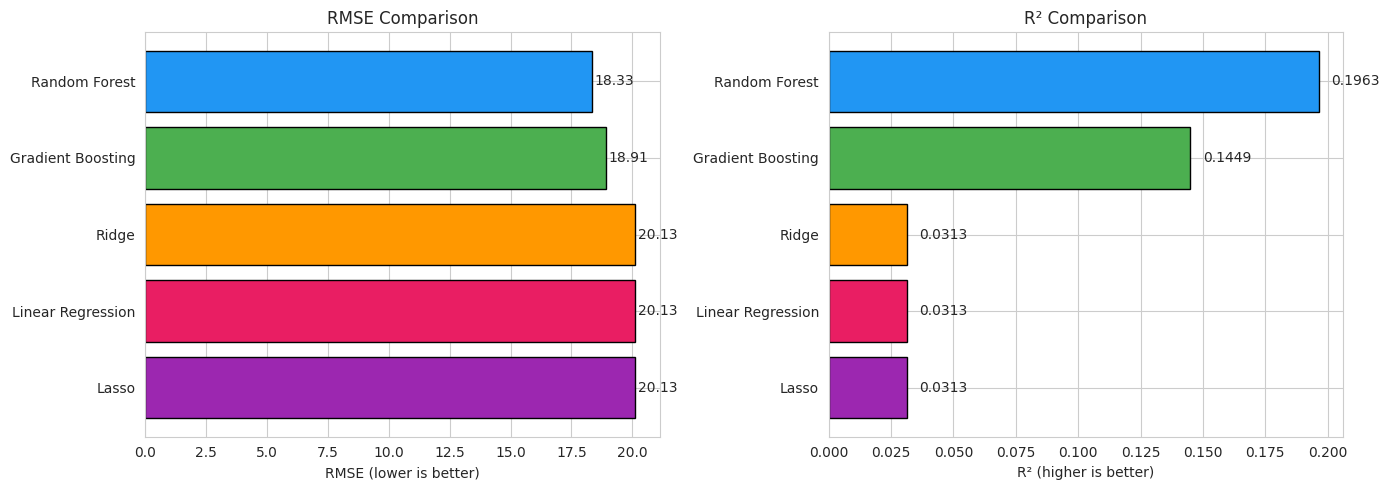

In [31]:
reg_results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso', 'Random Forest', 'Gradient Boosting'],
    'RMSE': [rmse_lr, rmse_ridge, rmse_lasso, rmse_rf, rmse_gb],
    'MAE': [mae_lr, mae_ridge, mae_lasso, mae_rf, mae_gb],
    'R²': [r2_lr, r2_ridge, r2_lasso, r2_rf, r2_gb]
}).sort_values('RMSE')

print(reg_results.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']

# RMSE
bars1 = axes[0].barh(reg_results['Model'], reg_results['RMSE'], color=colors, edgecolor='black')
axes[0].set_xlabel('RMSE (lower is better)')
axes[0].set_title('RMSE Comparison')
axes[0].invert_yaxis()
for bar, val in zip(bars1, reg_results['RMSE']):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center')

# R²
bars2 = axes[1].barh(reg_results['Model'], reg_results['R²'], color=colors, edgecolor='black')
axes[1].set_xlabel('R² (higher is better)')
axes[1].set_title('R² Comparison')
axes[1].invert_yaxis()
for bar, val in zip(bars2, reg_results['R²']):
    axes[1].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

plt.tight_layout()
plt.show()

### Comparison Interpretation

The chart shows a clear separation into **two groups**:

1. **Linear models** (Linear Regression, Ridge, Lasso): virtually identical performance among themselves, with R² ≈ 0.03. Regularization provides no improvement because the problem is not overfitting but the linear model's inability to capture the complexity of the problem.

2. **Ensemble models** (Random Forest, Gradient Boosting): significant improvement, with Random Forest leading (R² = 0.20).

The gap between both groups demonstrates that **non-linear relationships** exist between audio features and popularity that only tree-based models can capture (variable interactions, thresholds, combinations).

## 4.5. Predictions vs Actual Values (Best Model)

We visualize the best regression model's predictions against actual values.

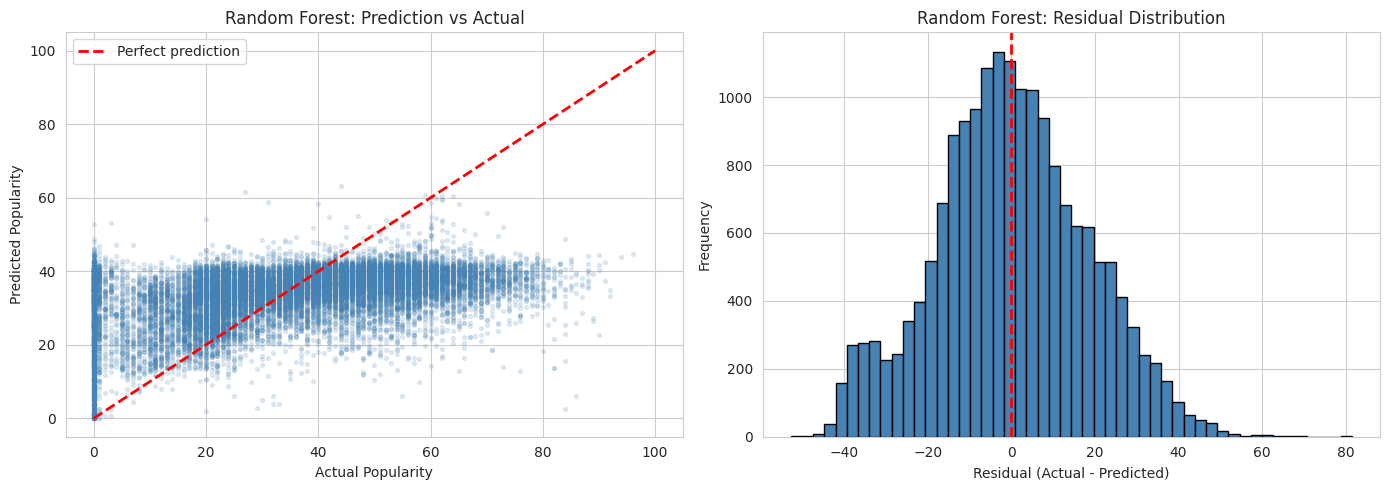

Mean residual: -0.023
Residual standard deviation: 18.334


In [32]:
# Select the best regression model by RMSE
best_reg_name = reg_results.iloc[0]['Model']
best_reg_preds = {'Linear Regression': y_pred_lr, 'Ridge': y_pred_ridge, 'Lasso': y_pred_lasso,
                  'Random Forest': y_pred_rf, 'Gradient Boosting': y_pred_gb}
y_pred_best = best_reg_preds[best_reg_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prediction vs actual scatter
axes[0].scatter(y_test, y_pred_best, alpha=0.15, s=8, color='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Popularity')
axes[0].set_ylabel('Predicted Popularity')
axes[0].set_title(f'{best_reg_name}: Prediction vs Actual')
axes[0].legend()

# Residual distribution
residuos = y_test - y_pred_best
axes[1].hist(residuos, bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_reg_name}: Residual Distribution')

plt.tight_layout()
plt.show()

print(f"Mean residual: {residuos.mean():.3f}")
print(f"Residual standard deviation: {residuos.std():.3f}")

### Residual Interpretation

- The **mean residual ≈ 0** confirms the model has no systematic bias: it does not consistently overestimate or underestimate popularity.
- The **standard deviation of 18.3** indicates high error dispersion: for a song with actual popularity of 50, the model could predict between 32 and 68 within a ±1σ interval.
- The prediction vs actual scatter shows a diffuse cloud far from the perfect diagonal, especially for extreme popularities (very low or very high).
- The residual distribution is approximately symmetric and centered at zero, which is correct — but its width confirms that audio features alone are insufficient to precisely predict popularity.

---

# 5. Classification Models

### Objective

Classify songs as **hit** (popularity > 49) or **no hit** using audio features.

This approach converts the problem into a binary classification task, useful for scenarios where detecting songs with high success potential is of interest.

## 5.1. Baseline Model: Logistic Regression

Linear baseline model for binary classification.

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Scale classification data
Xc_train_scaled = scaler.fit_transform(Xc_train)
Xc_test_scaled = scaler.transform(Xc_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(Xc_train_scaled, yc_train)
yc_pred_log = log_reg.predict(Xc_test_scaled)

print("=== Logistic Regression ===")
print(classification_report(yc_test, yc_pred_log, target_names=['No Hit', 'Hit']))

=== Logistic Regression ===
              precision    recall  f1-score   support

      No Hit       0.77      1.00      0.87     13789
         Hit       0.43      0.01      0.02      4159

    accuracy                           0.77     17948
   macro avg       0.60      0.50      0.44     17948
weighted avg       0.69      0.77      0.67     17948



### Interpretation

Logistic regression achieves an **accuracy of 77%**, but this figure is misleading:

- **Recall for "Hit" = 0.01**: out of 4,159 actual hits in the test set, the model barely detects a few. It predicts "No Hit" in 99% of cases.
- **Precision for "Hit" = 0.43**: when it ventures to predict "Hit", it is correct 43% of the time, but with such low recall that it is irrelevant.

Why? Logistic regression looks for a linear separating hyperplane. In a space where audio features do not clearly separate the classes, the model opts for the conservative strategy of predicting the majority class.

**Conclusion**: as a baseline, logistic regression confirms that a linear decision boundary is insufficient for this problem.

## 5.2. Tree-Based Models

### Random Forest Classifier

In [34]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(Xc_train, yc_train)
yc_pred_rf = rf_clf.predict(Xc_test)

print("=== Random Forest Classifier ===")
print(classification_report(yc_test, yc_pred_rf, target_names=['No Hit', 'Hit']))

=== Random Forest Classifier ===
              precision    recall  f1-score   support

      No Hit       0.77      1.00      0.87     13789
         Hit       0.65      0.03      0.05      4159

    accuracy                           0.77     17948
   macro avg       0.71      0.51      0.46     17948
weighted avg       0.74      0.77      0.68     17948



### Interpretation

Random Forest improves **precision for "Hit" to 0.65** — the highest of all models — but its **recall remains very low (0.03)**.

This means the model is very selective: when it predicts "Hit", it is correct 65% of the time, but it only identifies 3% of actual hits. It is a **conservative** model that prefers not to risk false positives.

The nature of bagging (averaging many trees) tends to smooth predictions toward the majority class, which explains this behavior.

### Gradient Boosting Classifier

In [35]:
gb_clf = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb_clf.fit(Xc_train, yc_train)
yc_pred_gb = gb_clf.predict(Xc_test)

print("=== Gradient Boosting Classifier ===")
print(classification_report(yc_test, yc_pred_gb, target_names=['No Hit', 'Hit']))

=== Gradient Boosting Classifier ===
              precision    recall  f1-score   support

      No Hit       0.78      0.99      0.87     13789
         Hit       0.56      0.05      0.09      4159

    accuracy                           0.77     17948
   macro avg       0.67      0.52      0.48     17948
weighted avg       0.72      0.77      0.69     17948



### Interpretation

Gradient Boosting achieves a slightly better balance: **precision = 0.56** and **recall = 0.05**, with F1 = 0.09.

Its sequential nature (each tree corrects errors from the previous one) gives it slightly more sensitivity to the minority class than Random Forest. Still, recall remains low — the model detects only 1 in every 20 actual hits.

The improvement over logistic regression is clear: boosting captures non-linear patterns that the linear model cannot.

## 5.3. Other Models

### K-Nearest Neighbors (KNN)

In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# KNN
knn = KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
knn.fit(Xc_train_scaled, yc_train)
yc_pred_knn = knn.predict(Xc_test_scaled)

print("=== K-Nearest Neighbors (k=7) ===")
print(classification_report(yc_test, yc_pred_knn, target_names=['No Hit', 'Hit']))

=== K-Nearest Neighbors (k=7) ===
              precision    recall  f1-score   support

      No Hit       0.79      0.91      0.85     13789
         Hit       0.40      0.20      0.26      4159

    accuracy                           0.75     17948
   macro avg       0.60      0.55      0.55     17948
weighted avg       0.70      0.75      0.71     17948



### Interpretation

KNN is the **most interesting classification model**, with very different results from the others:

| Metric | KNN | Best of rest (GB) |
|--------|-----|-------------------|
| Precision (Hit) | 0.40 | 0.56 |
| Recall (Hit) | **0.20** | 0.05 |
| F1 (Hit) | **0.26** | 0.09 |

- KNN detects **20% of actual hits** (recall = 0.20), compared to 5% for Gradient Boosting and 3% for Random Forest.
- It sacrifices precision (0.40 vs 0.56-0.65) in exchange for much higher recall.
- Its **F1 = 0.26** is ~3x higher than the second-best model.

Why does KNN work better here? By relying on nearest neighbors, KNN is sensitive to **local clusters** of hits in the feature space. Hits share audio patterns with other nearby hits, and KNN detects them without assuming a specific decision boundary shape.

### Overall Classification Conclusion

KNN emerges as the **best classification model**, not by accuracy (which is the lowest at 75%), but by its real ability to detect hits.

Ranking by F1-Score for the "Hit" class:

1. **KNN (k=7)**: F1 = 0.26 — best balance between detection and precision
2. Gradient Boosting: F1 = 0.09 — some detection but very conservative
3. Random Forest: F1 = 0.05 — high precision but minimal recall
4. Logistic Regression: F1 = 0.02 — practically useless for detecting hits

The key lesson is that **accuracy is not the appropriate metric** in imbalanced problems: the model with the worst accuracy (KNN, 75%) is the most useful for the actual objective (detecting hits).

## 5.4. Classification Model Comparison

All models are compared using Accuracy, Precision, Recall, and F1-score.

              Model  Accuracy  Precision  Recall     F1
          KNN (k=7)    0.7459     0.4010  0.1957 0.2630
  Gradient Boosting    0.7707     0.5558  0.0515 0.0942
      Random Forest    0.7711     0.6506  0.0260 0.0499
Logistic Regression    0.7677     0.4321  0.0084 0.0165


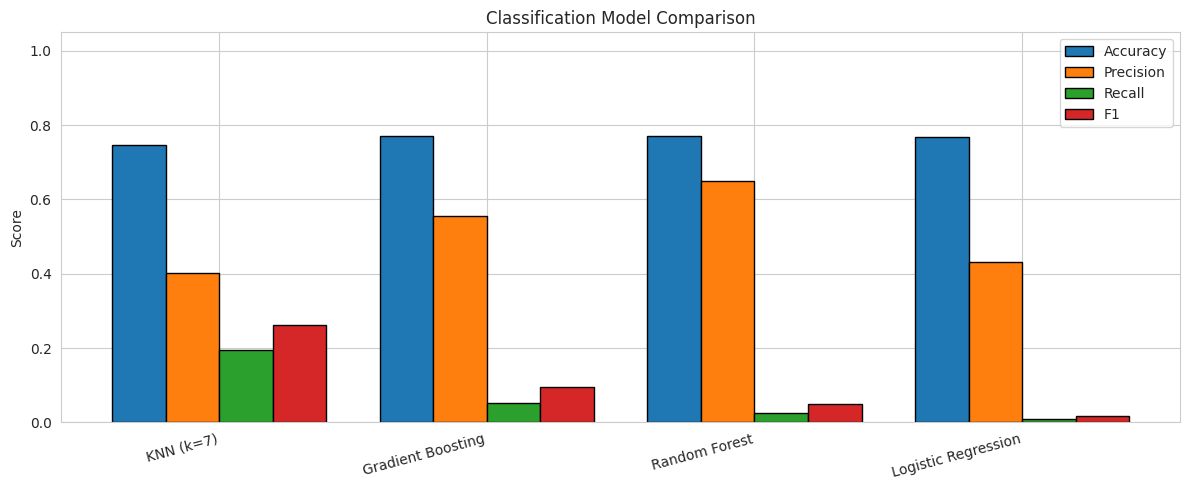

In [37]:
clf_models = {
    'Logistic Regression': yc_pred_log,
    'Random Forest': yc_pred_rf,
    'Gradient Boosting': yc_pred_gb,
    'KNN (k=7)': yc_pred_knn,
}

clf_results = []
for name, preds in clf_models.items():
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy_score(yc_test, preds),
        'Precision': precision_score(yc_test, preds, zero_division=0),
        'Recall': recall_score(yc_test, preds, zero_division=0),
        'F1': f1_score(yc_test, preds, zero_division=0)
    })

clf_results_df = pd.DataFrame(clf_results).sort_values('F1', ascending=False)
print(clf_results_df.round(4).to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(clf_results_df))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, clf_results_df[metric], width, label=metric, edgecolor='black')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(clf_results_df['Model'], rotation=15, ha='right')
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison')
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

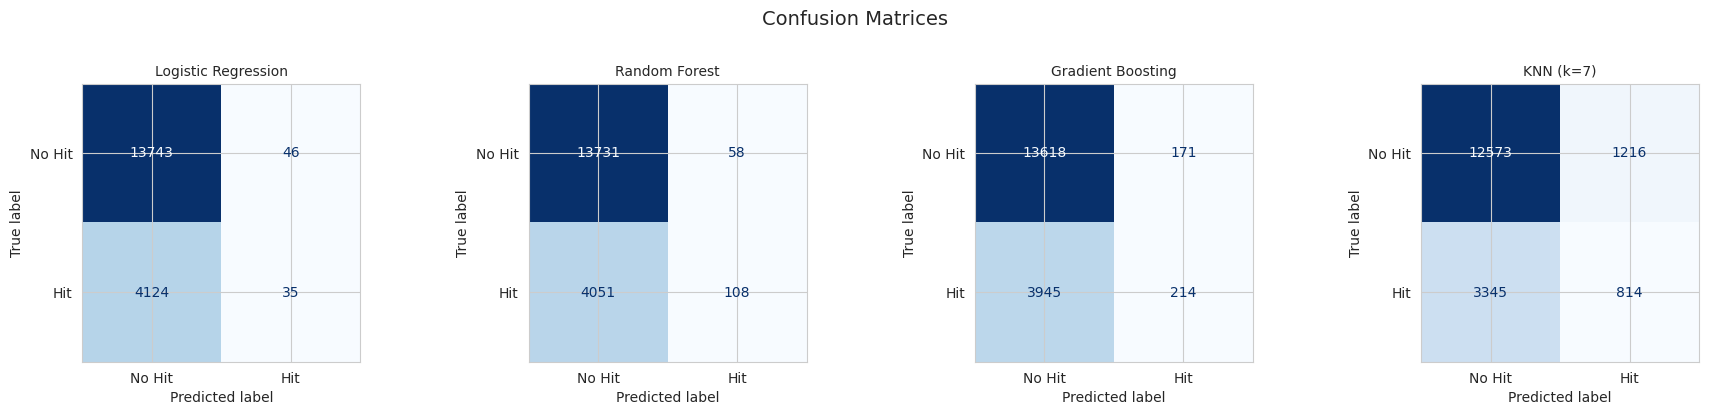

In [38]:
# Confusion matrices for the models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for idx, (name, preds) in enumerate(clf_models.items()):
    cm = confusion_matrix(yc_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Hit', 'Hit']).plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 5.5. Classification Conclusions

| Finding | Detail |
|---------|--------|
| KNN is the best classifier | F1 = 0.26 for "Hit", detects 20% of actual hits |
| Accuracy is misleading | All models hover around 75-77%, but their real utility varies enormously |
| Tree models are conservative | High precision but very low recall (3-5%) — they prefer not to take risks |
| KNN exploits local structure | Hits form clusters in the feature space that KNN can detect |

**Why are results moderate?** Even with a more permissive threshold (P75), audio features alone do not fully determine whether a song will be popular. External factors (artist, release timing, playlist presence) remain decisive.

**For improvement**: techniques like `class_weight='balanced'`, decision threshold adjustment, or SMOTE could be applied to boost hit detection.

---

# 6. Global Evaluation and Comparison

### Objective

Consolidate regression and classification results in a unified view to select the best models.

## 6.1. Regression Summary

In [39]:
print("=== Regression Model Summary ===\n")
print(reg_results.round(4).to_string(index=False))
print(f"\nBest model (lowest RMSE): {reg_results.iloc[0]['Model']}")
print(f"  RMSE = {reg_results.iloc[0]['RMSE']:.3f}  |  R² = {reg_results.iloc[0]['R²']:.4f}")

=== Regression Model Summary ===

            Model    RMSE     MAE     R²
    Random Forest 18.3336 14.5888 0.1963
Gradient Boosting 18.9110 15.1576 0.1449
            Ridge 20.1278 16.5837 0.0313
Linear Regression 20.1278 16.5837 0.0313
            Lasso 20.1285 16.6134 0.0313

Best model (lowest RMSE): Random Forest
  RMSE = 18.334  |  R² = 0.1963


### Interpretation

The jump from R² = 0.03 (linear models) to R² = 0.20 (Random Forest) confirms that non-linear patterns exist in the data. However, the R² = 0.20 ceiling indicates that 80% of popularity variability cannot be explained with audio features.

This does not mean the models are useless: an RMSE of ~18 points at least allows **relatively ordering** tracks by expected popularity, even if it cannot predict their exact score.

## 6.2. Classification Summary

In [40]:
print("=== Classification Model Summary ===\n")
print(clf_results_df.round(4).to_string(index=False))
print(f"\nBest model (highest F1): {clf_results_df.iloc[0]['Model']}")
print(f"  F1 = {clf_results_df.iloc[0]['F1']:.4f}  |  Recall = {clf_results_df.iloc[0]['Recall']:.4f}")

=== Classification Model Summary ===

              Model  Accuracy  Precision  Recall     F1
          KNN (k=7)    0.7459     0.4010  0.1957 0.2630
  Gradient Boosting    0.7707     0.5558  0.0515 0.0942
      Random Forest    0.7711     0.6506  0.0260 0.0499
Logistic Regression    0.7677     0.4321  0.0084 0.0165

Best model (highest F1): KNN (k=7)
  F1 = 0.2630  |  Recall = 0.1957


### Interpretation

With the P75 threshold (popularity > 49), classification models show significant differences:

- **KNN** stands out clearly with F1 = 0.26, the only model achieving a reasonable balance between detection and precision.
- Tree-based models (RF, GB) are very conservative: they prioritize precision over recall, detecting few hits.
- Logistic regression is practically useless as a hit classifier.

The difference between accuracy (~75% for all) and F1 (from 0.02 to 0.26) illustrates why **metric choice is critical** in imbalanced problems.

## 6.3. Global Comparative Visualization

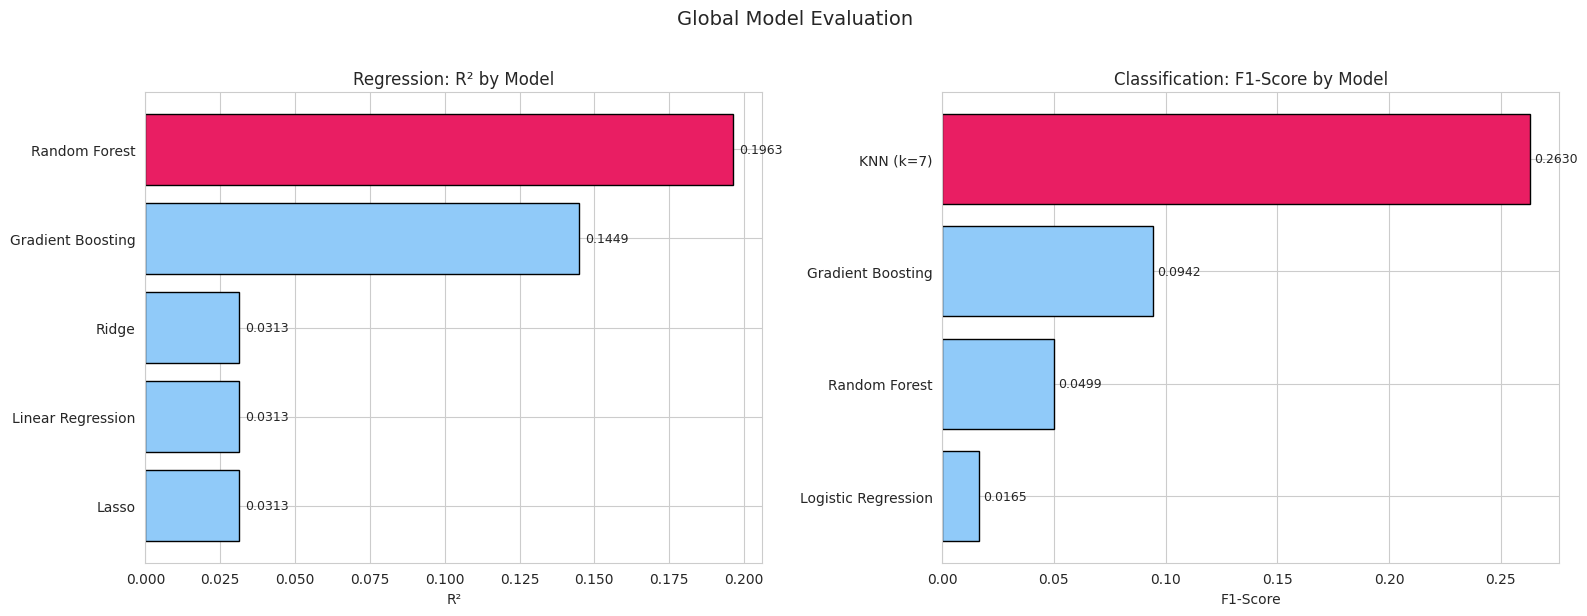

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Regression: R² ---
reg_sorted = reg_results.sort_values('R²', ascending=True)
colors_reg = ['#E91E63' if v == reg_sorted['R²'].max() else '#90CAF9' for v in reg_sorted['R²']]
axes[0].barh(reg_sorted['Model'], reg_sorted['R²'], color=colors_reg, edgecolor='black')
axes[0].set_xlabel('R²')
axes[0].set_title('Regression: R² by Model')
for i, (val, modelo) in enumerate(zip(reg_sorted['R²'], reg_sorted['Model'])):
    axes[0].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

# --- Classification: F1 ---
clf_sorted = clf_results_df.sort_values('F1', ascending=True)
colors_clf = ['#E91E63' if v == clf_sorted['F1'].max() else '#90CAF9' for v in clf_sorted['F1']]
axes[1].barh(clf_sorted['Model'], clf_sorted['F1'], color=colors_clf, edgecolor='black')
axes[1].set_xlabel('F1-Score')
axes[1].set_title('Classification: F1-Score by Model')
for i, (val, modelo) in enumerate(zip(clf_sorted['F1'], clf_sorted['Model'])):
    axes[1].text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Global Model Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Observations

- In **regression**, ensemble models (Random Forest, Gradient Boosting) clearly outperform linear models. Random Forest leads with R² = 0.20, versus R² = 0.03 for linear regression — a ×6 improvement.
- In **classification**, KNN is the most capable model for detecting hits (F1 = 0.26), while tree-based models prioritize precision over recall.
- There is an **interesting asymmetry**: Random Forest is the best in regression, but KNN surpasses it in classification. This suggests the problem structure changes depending on how it is formulated (continuous value vs binary class).
- No model achieves high performance in absolute terms, but all confirm that **audio features contain useful, albeit limited, predictive information**.

## 6.4. Best Model Selection

| Task | Best Model | Key Metric | Result |
|------|-----------|------------|--------|
| **Regression** | Random Forest | R² = 0.20, RMSE = 18.3 | Captures 20% of variance |
| **Classification** | KNN (k=7) | F1 = 0.26, Recall = 0.20 | Detects 1 in 5 hits |

**Justification**:
- **Random Forest (regression)**: lowest RMSE and highest R². Its ability to model non-linear interactions is key.
- **KNN (classification)**: despite its lower accuracy, it is the only model with real hit detection capability. Its local neighborhood-based approach is more effective for this problem than global models.

## 6.5. Reflection on Predictive Capability

- Even the best regression model explains a limited fraction of popularity variance.
- This does not invalidate the analysis: it confirms that Spotify popularity largely depends on **external** factors beyond audio (marketing, artist, timing, editorial playlists, social media virality).
- Audio features provide a useful signal but one insufficient on its own to predict success with high precision.

---

# 7. Model Interpretation

### Objective

Analyze which variables most influence model predictions and extract interpretable conclusions for decision-making.

## 7.1. Feature Importance (Random Forest — Regression)

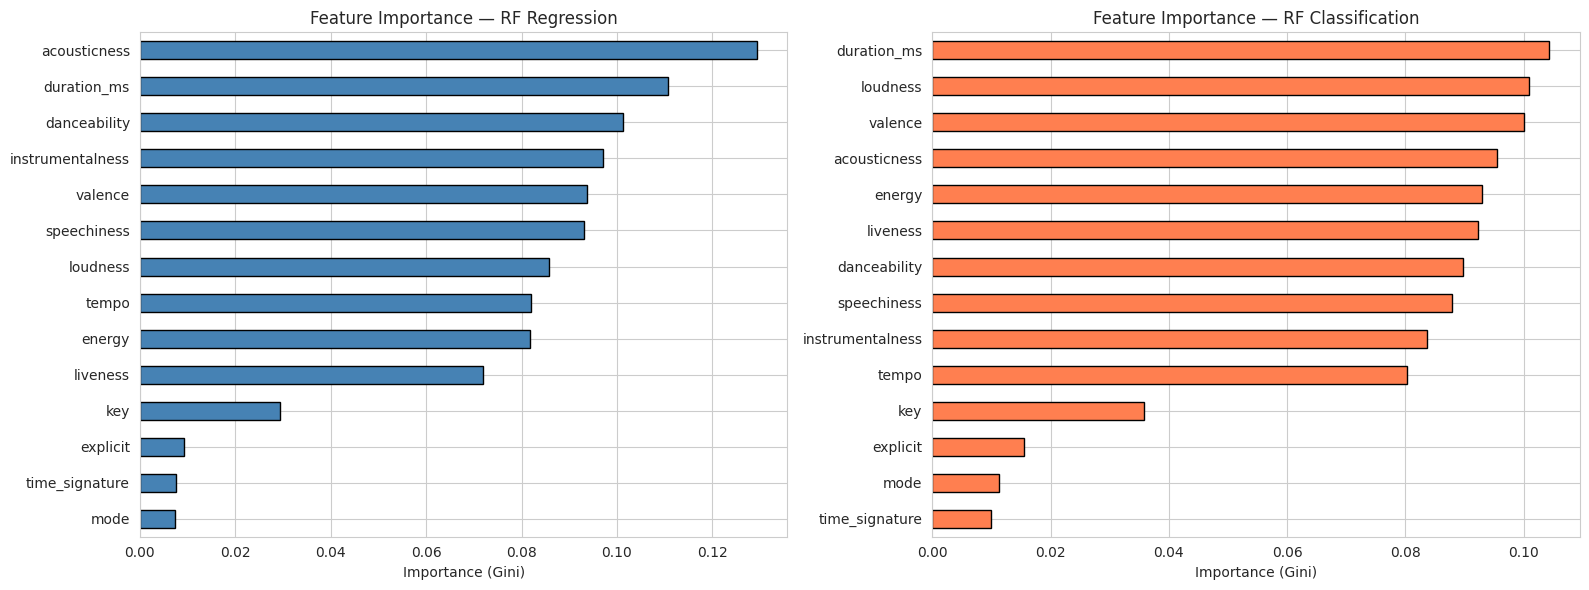

Top 5 features (regression):
  acousticness         0.1293
  duration_ms          0.1106
  danceability         0.1012
  instrumentalness     0.0971
  valence              0.0938

Top 5 features (classification):
  duration_ms          0.1043
  loudness             0.1008
  valence              0.1001
  acousticness         0.0956
  energy               0.0930


In [42]:
# Random Forest Regressor feature importance
importances_reg = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Regression
importances_reg.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Feature Importance — RF Regression')
axes[0].set_xlabel('Importance (Gini)')

# Classification
importances_clf = pd.Series(rf_clf.feature_importances_, index=X_class.columns).sort_values(ascending=True)
importances_clf.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Feature Importance — RF Classification')
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.show()

print("Top 5 features (regression):")
for name, val in importances_reg.sort_values(ascending=False).head(5).items():
    print(f"  {name:20s} {val:.4f}")
print()
print("Top 5 features (classification):")
for name, val in importances_clf.sort_values(ascending=False).head(5).items():
    print(f"  {name:20s} {val:.4f}")

### Feature Importance Interpretation

**In regression** (continuous popularity prediction):
- **Acousticness** (0.129) and **duration_ms** (0.111) are the most important, followed by **danceability** (0.101) and **instrumentalness** (0.097).
- Importance is relatively distributed: no single variable dominates. This confirms that popularity is a multicausal phenomenon.
- The top 5 variables account for ~53% of total importance, while the remaining 47% is distributed among the others.

**In classification** (hit detection):
- The ranking may vary slightly from regression since the objective is different: separating "Hit" from "No Hit" vs predicting a continuous value.
- The variables that best discriminate between the two classes are not necessarily the same ones that best predict the exact popularity value.

**Key conclusion**: no single variable alone explains popularity. It is the **combination** of multiple features that tree models leverage to improve their predictions.

## 7.2. Linear Model Coefficients

The standardized coefficients of the linear regression model allow interpreting the direction and magnitude of each variable's effect.

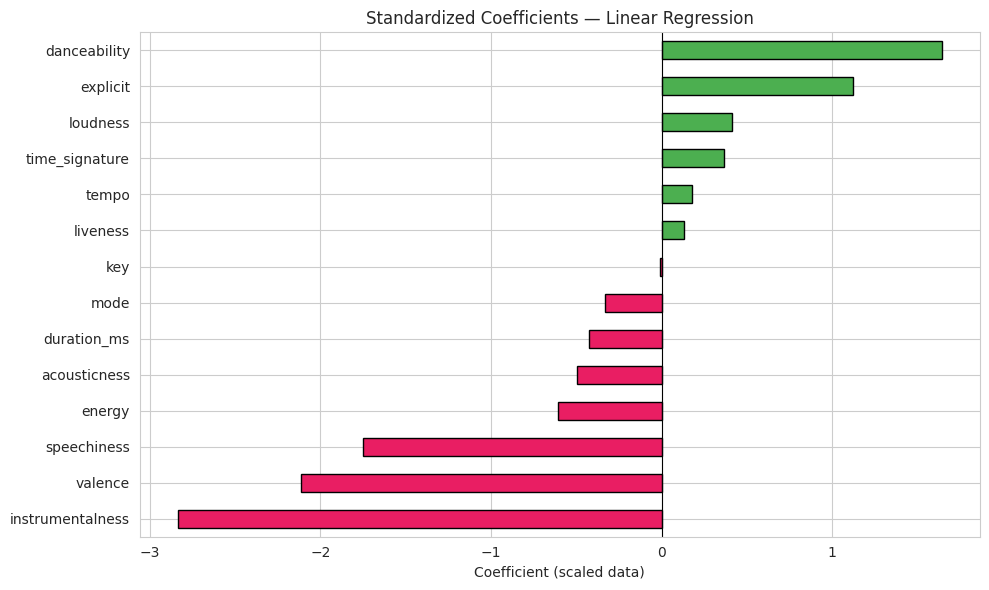

Coefficients (sorted by absolute magnitude):
  instrumentalness     -2.8356
  valence              -2.1170
  speechiness          -1.7518
  danceability         +1.6424
  explicit             +1.1211
  energy               -0.6062
  acousticness         -0.4934
  duration_ms          -0.4249
  loudness             +0.4125
  time_signature       +0.3680
  mode                 -0.3294
  tempo                +0.1794
  liveness             +0.1286
  key                  -0.0113


In [43]:
# Standardized linear regression coefficients
coefs = pd.Series(lr.coef_, index=X.columns).sort_values()

plt.figure(figsize=(10, 6))
colors = ['#E91E63' if v < 0 else '#4CAF50' for v in coefs]
coefs.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Standardized Coefficients — Linear Regression')
plt.xlabel('Coefficient (scaled data)')
plt.tight_layout()
plt.show()

print("Coefficients (sorted by absolute magnitude):")
for name, val in coefs.abs().sort_values(ascending=False).items():
    direction = "+" if coefs[name] > 0 else "-"
    print(f"  {name:20s} {direction}{val:.4f}")

### Coefficient Interpretation

The standardized coefficients reveal the **direction and magnitude** of each variable's effect in the linear model:

**Negative effects** (reduce predicted popularity):
- **Instrumentalness** (−2.84): the strongest negative effect. Tracks without vocals are significantly less popular. This makes sense: Spotify's mainstream audience prefers songs with lyrics.
- **Valence** (−2.12): happier-sounding songs tend to be less popular, a surprising result that could reflect the predominance of hits with emotional or melancholic themes.
- **Speechiness** (−1.75): too much spoken word presence (podcasts, spoken word) reduces popularity in the music context.

**Positive effects** (increase predicted popularity):
- **Danceability** (+1.64): danceable songs tend to be more popular. Consistent with pop, reggaeton, and k-pop trends.
- **Explicit** (+1.12): songs with explicit content tend to be more popular — possibly because more mainstream artists use explicit content more frequently.

> **Important**: these coefficients are from the linear model (R² = 0.03), so their explanatory power is limited. They show general trends but do not capture the non-linear interactions that tree models capture.

## 7.3. Partial Dependence Analysis

The marginal relationships of the most important variables with predicted popularity are analyzed using partial dependence plots from the Gradient Boosting model.

/home/robert/.local/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


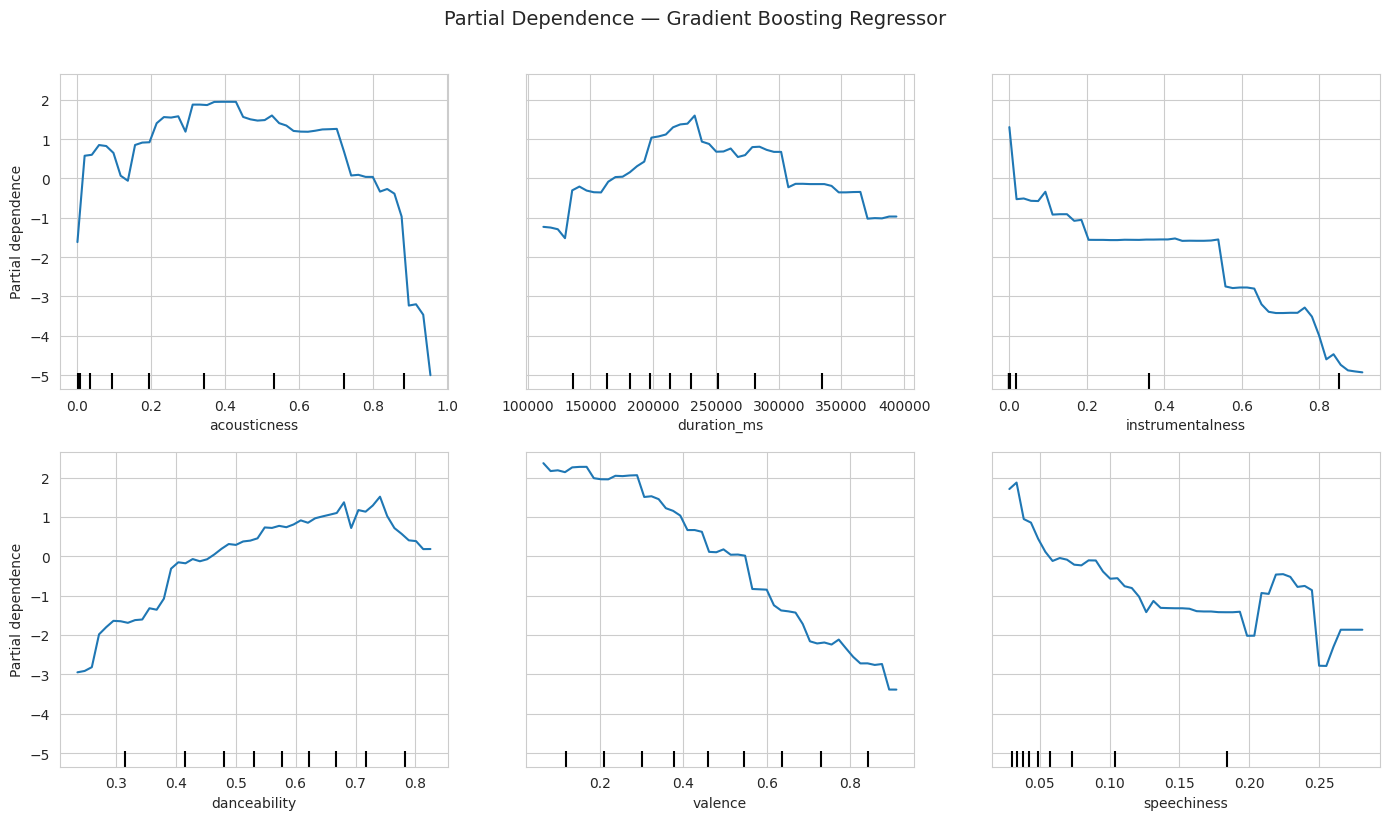

In [44]:
from sklearn.inspection import PartialDependenceDisplay

# Top 6 variables by importance in GB Regressor
top_features_gb = pd.Series(gb_reg.feature_importances_, index=X.columns).sort_values(ascending=False).head(6).index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
PartialDependenceDisplay.from_estimator(
    gb_reg, X_test, features=top_features_gb,
    ax=ax, grid_resolution=50, n_cols=3
)
fig.suptitle('Partial Dependence — Gradient Boosting Regressor', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Partial Dependence Interpretation

Partial dependence plots show how the **average prediction** of the model changes when a variable is modified while keeping the others constant. Unlike linear coefficients, here we can observe **non-linear relationships**:

- **Instrumentalness**: predicted popularity drops sharply for values > 0.1. The relationship is not gradual but presents a "threshold effect": it is enough for a song to be slightly instrumental to lose popularity.
- **Duration_ms**: an optimal duration range is observed. Songs that are too short or too long have lower predicted popularity, with a "sweet spot" reflecting the standard pop song duration (~3-4 minutes).
- **Acousticness**: shows a non-linear relationship. Very high values reduce popularity, but intermediate values don't affect it as much — there is room for semi-acoustic tracks.
- **Danceability/Energy**: show more monotonic relationships — higher danceability or energy leads to higher predicted popularity, with diminishing returns at the extremes.

These curves explain why tree models outperform linear ones: the real relationships between audio and popularity **are not straight lines**, but functions with thresholds, saturations, and non-trivial shapes.

## 7.4. Interpretation Conclusions

- **Instrumentalness** is consistently the most influential variable: instrumental tracks have significantly less popularity. This makes sense given that Spotify's mainstream audience consumes songs with vocals.
- **Loudness**, **danceability**, and **energy** contribute positively to popularity, reflecting general audience preferences for energetic and danceable music.
- **Acousticness** shows a moderate negative effect: more acoustic productions tend to be less popular on average.
- **Duration_ms** shows relevance in tree models: songs that are too long or too short fall outside the optimal popularity range.
- Partial dependence plots reveal non-linear relationships that linear models cannot capture, explaining the superiority of ensemble models.

---

# 8. Conclusions

## 8.1. Project Summary

A complete analysis of ~89,740 unique Spotify tracks was performed, spanning from data exploration to machine learning model construction and interpretation.

The analysis followed a professional data science workflow:

1. **Exploration and cleaning** → Identification of duplicates, null values, and outliers  
2. **EDA** → Distributions, genre analysis, correlations  
3. **Preparation** → Feature engineering, train/test split, scaling, "hit" variable definition (P75 threshold)  
4. **Modeling** → 5 regression models + 4 classification models  
5. **Evaluation** → Rigorous comparison with appropriate metrics (R², RMSE, F1)  
6. **Interpretation** → Feature importance, partial dependence, coefficients  

## 8.2. Main Findings

| Finding | Detail |
|---------|--------|
| Popularity is not explained solely by audio | Best R² = 0.20 (Random Forest), confirming that external factors are decisive |
| **Instrumentalness** is the most influential variable | Strong negative effect: tracks without vocals are much less popular |
| Ensemble models outperform linear models ×6 | R² = 0.20 vs 0.03 — non-linear relationships are key |
| KNN is the best hit classifier | F1 = 0.26, detects 20% of hits; local neighborhood surpasses global models |
| Musical genre is a strong proxy | K-pop, pop-film, and metal lead; iranian, romance, and jazz fall well below |
| Metric choice is critical | Accuracy is misleading in imbalanced classification — F1 and Recall are the relevant metrics |

## 8.3. Limitations

- The dataset only includes **audio features** and basic metadata; it does not capture factors like playlist presence, marketing campaigns, artist follower count, or temporal context.
- The `popularity` variable is a **snapshot** in time and can vary significantly.
- The "hit" threshold (popularity > 49, P75) is a design decision that affects classification results.
- Exhaustive hyperparameter optimization (GridSearch/RandomSearch) was not performed, which could improve results.
- Classification models show moderate performance, evidencing the problem's complexity.

## 8.4. Possible Future Directions

- Incorporate **external data** (artist followers, playlist presence, release date) to improve predictive capability.
- Apply techniques like **class_weight='balanced'** or **SMOTE** to boost hit detection.
- Optimize hyperparameters with **RandomizedSearchCV** or **Optuna**.
- Explore **deep learning** models to capture more complex patterns.
- Analyze the **temporal evolution** of musical trends.
- Test different **hit thresholds** to study result sensitivity.

## 8.5. Final Conclusion

Spotify audio features allow identifying **significant patterns** related to a song's popularity. Tree models capture non-linear relationships (R² = 0.20) that linear models do not detect (R² = 0.03), and KNN manages to detect 1 in 5 actual hits in classification.

However, musical popularity is a **multifactorial** phenomenon where audio is just one piece of the puzzle. 80% of the variance remains unexplained, reflecting the importance of factors external to sound.

This analysis provides value as a complementary tool for the music industry: not as a definitive success predictor, but as a **signal detection** system that, combined with contextual information, can support strategic decisions in music content selection and promotion.